<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>03 $\rightarrow$ Hierarchical Face & Eye Detection</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Hierarchical Region-of-Interest Pipeline for Robust Eye Localization)</span>
</div>

---

## Overview
In this notebook, we implement **Hierarchical Region of Interest (ROI)** detection:
1. Detect the **face** bounding box $(x, y, w, h)$ first.
2. Constrain eye detection strictly inside the **upper portion of the face ROI**.

### Why Hierarchical Detection is Superior:
- **Accuracy**: Restricts eye search strictly to the eye-level region of the face.
- **Speed**: Searching a small face sub-region is much faster than scanning the entire canvas.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load Face and Eye Classifiers](#2-load-face-and-eye-classifiers)
3. [Load and Prepare the Input Image](#3-load-and-prepare-the-input-image)
4. [Hierarchical Detection Function](#4-hierarchical-detection-function)
5. [Visualizations](#5-visualizations)
   - 5.1 [Plot 1: Side-by-Side Detection Overview](#51-plot-1-side-by-side-detection-overview)
   - 5.2 [Plot 2: Multi-Level Breakdown (Face ROI & Isolated Eyes)](#52-plot-2-multi-level-breakdown-face-roi-isolated-eyes)
6. [Key Takeaways](#6-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a id="2-load-face-and-eye-classifiers"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load Face and Eye Classifiers</span>

In [2]:
face_cascade_path = 'Haarcascades/haarcascade_frontalface_default.xml'
eye_cascade_path = 'Haarcascades/haarcascade_eye.xml'

face_classifier = cv2.CascadeClassifier(face_cascade_path)
eye_classifier = cv2.CascadeClassifier(eye_cascade_path)

if face_classifier.empty() or eye_classifier.empty():
    print("Error loading cascade files!")
else:
    print("Both Face and Eye classifiers loaded successfully!")

Both Face and Eye classifiers loaded successfully!


<a id="3-load-and-prepare-the-input-image"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Load and Prepare the Input Image</span>

In [3]:
image_bgr = cv2.imread('assets/images/eye_face.jpg')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image Dimensions: {image_rgb.shape[1]} x {image_rgb.shape[0]} px")

Image Dimensions: 1024 x 1024 px


<a id="4-hierarchical-detection-function"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Hierarchical Detection Function</span>

- First, detect the face on `image_gray`.
- Extract `roi_gray` and search the upper $58\%$ of the face (`upper_h = int(h * 0.58)`).
- Draw the face in red `(255, 0, 0)` and eyes in blue `(0, 0, 255)` with green center markers.

In [4]:
def detect_faces_and_eyes(image_rgb, image_gray):
    canvas = image_rgb.copy()
    faces = face_classifier.detectMultiScale(image_gray, scaleFactor=1.3, minNeighbors=5)
    
    detection_data = []
    
    for (x, y, w, h) in faces:
        # Draw face rectangle in basic red
        cv2.rectangle(canvas, (x, y), (x + w, y + h), (255, 0, 0), 5)
        cv2.putText(canvas, "Face", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
        
        # Constrain eye search to the upper 58% of the face ROI
        upper_h = int(h * 0.58)
        roi_gray_upper = image_gray[y:y+upper_h, x:x+w]
        roi_color = canvas[y:y+h, x:x+w]
        
        eyes = eye_classifier.detectMultiScale(
            roi_gray_upper,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50)
        )
        eyes = sorted(eyes, key=lambda b: b[0])
        
        for (ex, ey, ew, eh) in eyes:
            # Draw eye rectangle in basic blue
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 3)
            # Mark eye center
            cv2.circle(roi_color, (ex + ew // 2, ey + eh // 2), 4, (0, 255, 0), -1)
            
        detection_data.append({
            'face_box': (x, y, w, h),
            'eye_boxes': eyes
        })
        
    return canvas, detection_data

hierarchical_result, detection_data = detect_faces_and_eyes(image_rgb, image_gray)

print(f"Faces detected: {len(detection_data)}")
if len(detection_data) > 0:
    print(f"Eyes detected inside face: {len(detection_data[0]['eye_boxes'])}")

Faces detected: 1


Eyes detected inside face: 2


<a id="5-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Visualizations</span>

<a id="51-plot-1-side-by-side-detection-overview"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Plot 1: Side-by-Side Detection Overview</span>

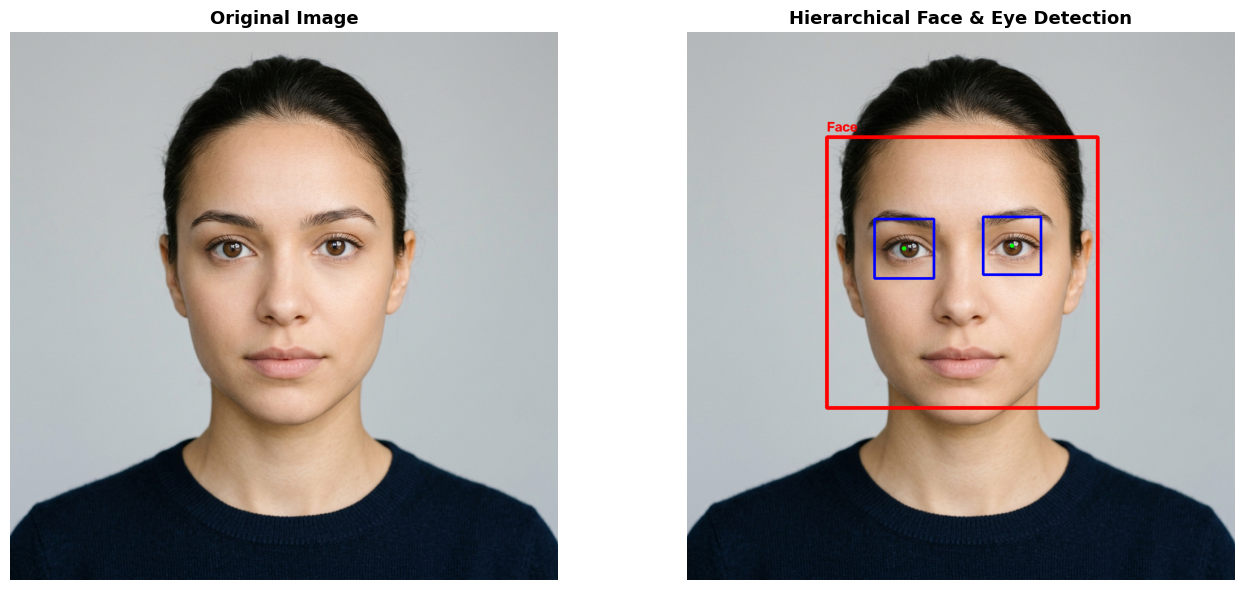

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(hierarchical_result)
axes[1].set_title("Hierarchical Face & Eye Detection", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

<a id="52-plot-2-multi-level-breakdown-face-roi-isolated-eyes"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Plot 2: Multi-Level Breakdown (Face ROI & Isolated Eyes)</span>

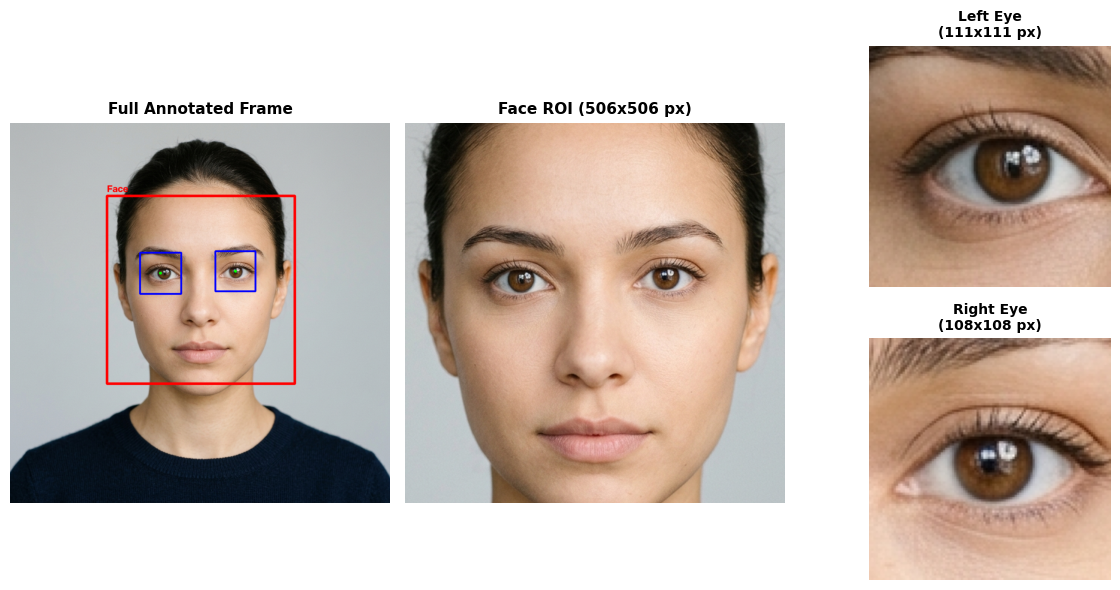

In [6]:
if len(detection_data) > 0:
    fx, fy, fw, fh = detection_data[0]['face_box']
    eyes = detection_data[0]['eye_boxes']
    
    fig = plt.figure(figsize=(12, 6))
    
    # 1. Full Image
    ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
    ax1.imshow(hierarchical_result)
    ax1.set_title("Full Annotated Frame", fontsize=11, fontweight='bold')
    ax1.axis('off')
    
    # 2. Face ROI
    ax2 = plt.subplot2grid((2, 3), (0, 1), rowspan=2)
    face_crop = image_rgb[fy:fy+fh, fx:fx+fw]
    ax2.imshow(face_crop)
    ax2.set_title(f"Face ROI ({fw}x{fh} px)", fontsize=11, fontweight='bold')
    ax2.axis('off')
    
    # 3. Individual Eyes (Left & Right)
    eye_labels = ["Left Eye", "Right Eye"]
    for i, (ex, ey, ew, eh) in enumerate(eyes[:2]):
        ax_eye = plt.subplot2grid((2, 3), (i, 2))
        eye_crop = face_crop[ey:ey+eh, ex:ex+ew]
        ax_eye.imshow(eye_crop)
        ax_eye.set_title(f"{eye_labels[i]}\n({ew}x{eh} px)", fontsize=10, fontweight='bold')
        ax_eye.axis('off')
        
    plt.tight_layout()
    plt.show()

<a id="6-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Key Takeaways</span>

- **Hierarchical Workflow**: Detecting the coarse object (face) first and localizing fine features (eyes) within it is standard computer vision architecture.
- **ROI Optimization**: Constraining searches to relevant regions boosts processing speed and guarantees high accuracy.
- **Next Step**: In Notebook 04, we transition to dynamic video streams for pedestrian tracking.